## B1. Class Distribution

The following visualization shows the number of image samples available for each plant species category. This analysis helps identify whether the dataset is balanced and whether additional preprocessing techniques may be necessary to address class imbalance.

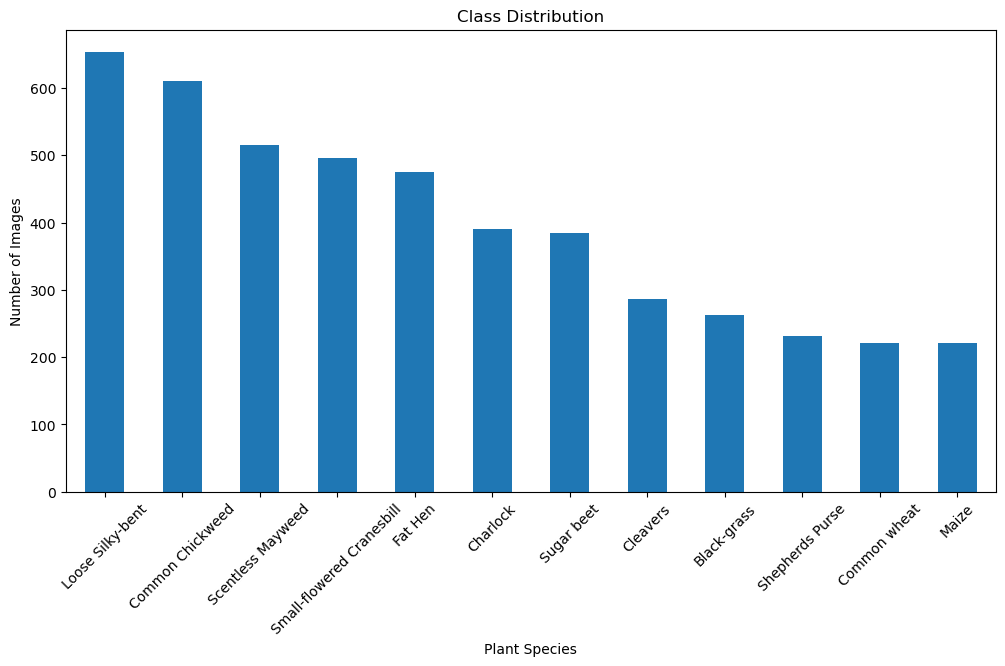

Label
Loose Silky-bent             654
Common Chickweed             611
Scentless Mayweed            516
Small-flowered Cranesbill    496
Fat Hen                      475
Charlock                     390
Sugar beet                   385
Cleavers                     287
Black-grass                  263
Shepherds Purse              231
Common wheat                 221
Maize                        221
Name: count, dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

labels = pd.read_csv("data/labels.csv")
class_counts = labels['Label'].value_counts()

os.makedirs("Figures", exist_ok=True)

plt.figure(figsize=(12,6))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Plant Species')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.savefig("Figures/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(class_counts)

### Report Discussion

The class distribution visualization showed that the dataset is moderately imbalanced across the 12 plant species categories; however, all classes contain sufficient observations to support multiclass image classification.

## Sample Images from Each Class

The following images represent examples from multiple plant species categories contained in the dataset. Visual inspection helps verify image quality, labeling consistency, and distinguishable visual patterns among classes.

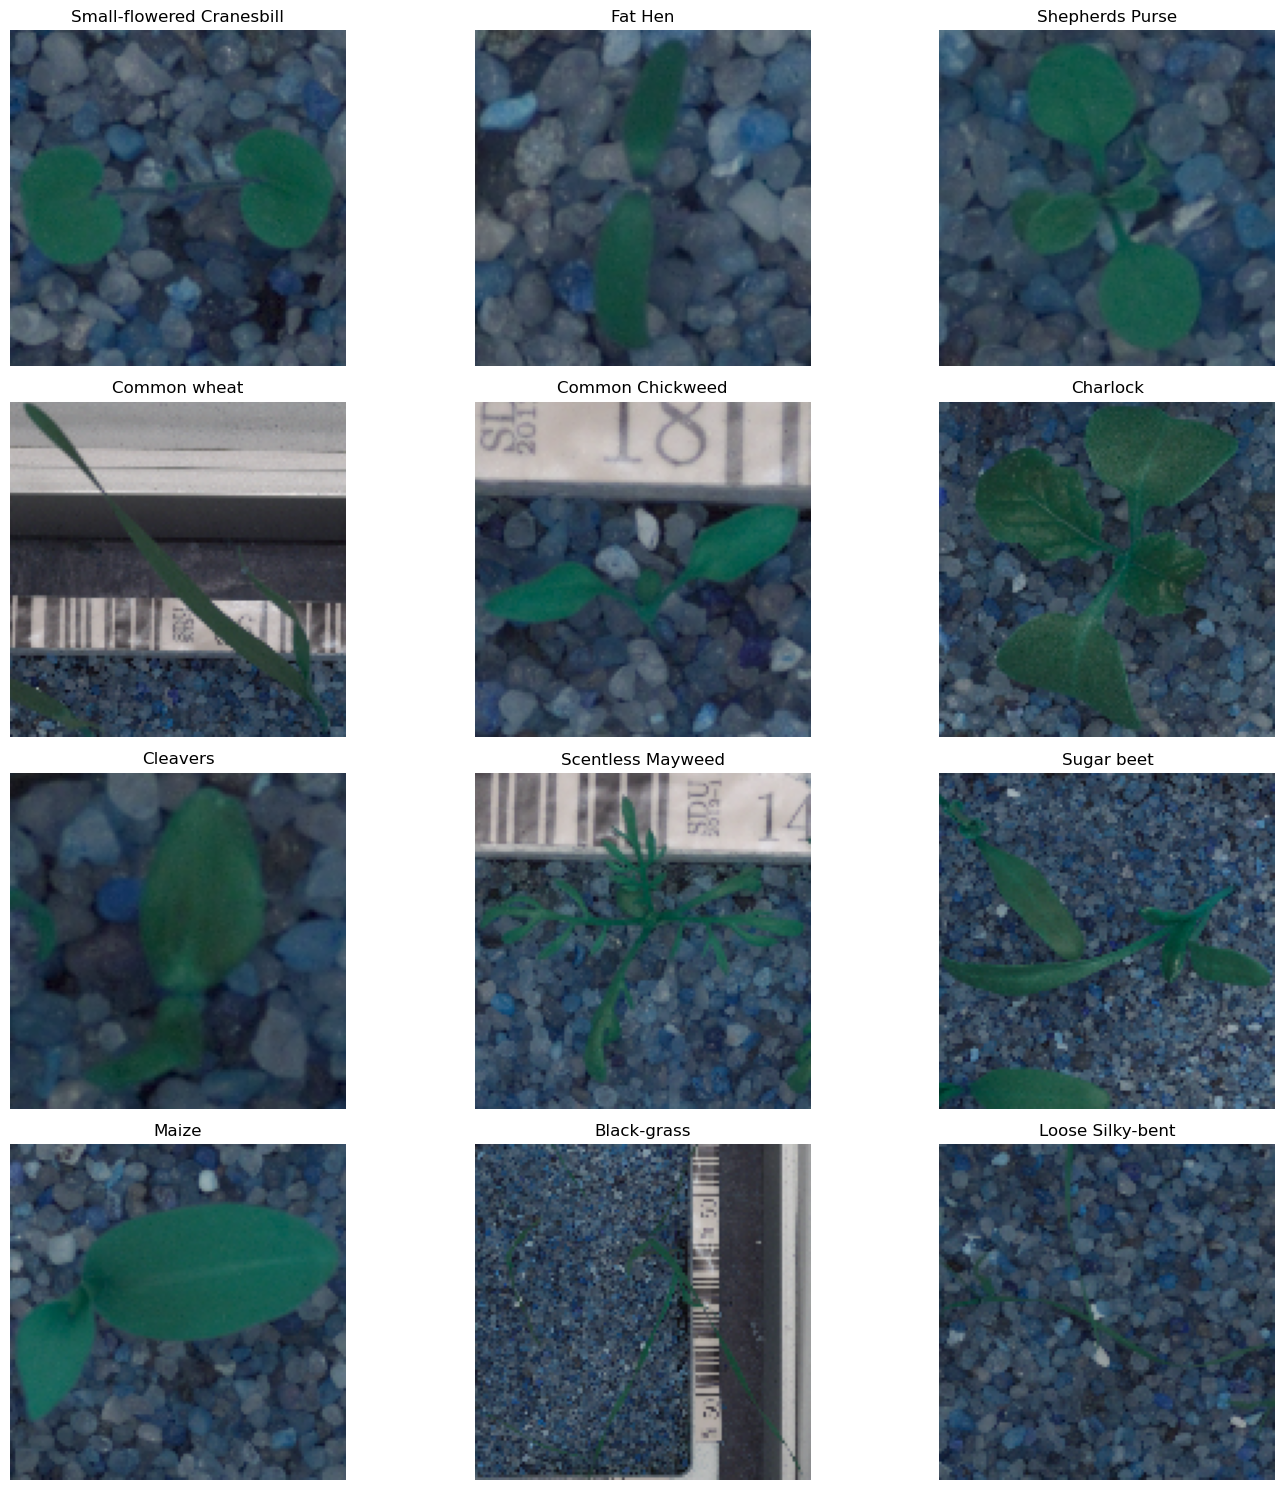

In [2]:
import numpy as np

unique_classes = labels['Label'].unique()

images = np.load("data/images.npy")

plt.figure(figsize=(15,15))

for i, plant_class in enumerate(unique_classes[:12]):
    idx = labels[labels['Label'] == plant_class].index[0]

    plt.subplot(4,3,i+1)
    plt.imshow(images[idx])
    plt.title(plant_class)
    plt.axis('off')

plt.tight_layout()
plt.savefig("Figures/SampleImages.png", dpi=300, bbox_inches="tight")
plt.show()

### Report Discussion

The sample images demonstrate visible differences in leaf structure, texture, shape, and color among the plant species. Some species appear visually similar during early growth stages, which increases classification complexity and makes the problem appropriate for deep learning and computer vision techniques.

## Dataset Characteristics

The following section summarizes the dataset dimensions, image properties, and statistical characteristics of the image pixel values.

In [3]:
print("Image Dataset Shape:", images.shape)
print("Label Dataset Shape:", labels.shape)

print("\n", "Pixel Value Statistics")
print("Minimum Pixel Value:", images.min())
print("Maximum Pixel Value:", images.max())
print("Mean Pixel Value:", images.mean())
print("Standard Deviation:", images.std())

Image Dataset Shape: (4750, 128, 128, 3)
Label Dataset Shape: (4750, 1)

 Pixel Value Statistics
Minimum Pixel Value: 0
Maximum Pixel Value: 255
Mean Pixel Value: 70.04363745545504
Standard Deviation: 31.996876308515


### Report Discussion

The dataset contains 4,750 RGB images with dimensions of 128 × 128 × 3. Pixel values range from 0 to 255 because the images are stored using standard 8-bit color encoding. Summary statistics were analyzed to better understand image intensity distribution prior to normalization.

The dataset size is appropriate for convolutional neural network training while remaining computationally manageable in the WGU Assessment Lab environment.

---
## B2. Preprocessing Steps


## Image Resizing

Images were resized to a consistent 128 × 128 dimension to standardize inputs for the convolutional neural network.

In [4]:
import cv2

resized_images = np.array([
cv2.resize(img, (128, 128)) for img in images
])

print(resized_images.shape)

(4750, 128, 128, 3)


## Image Normalization

Pixel values were scaled from the original range of 0–255 to a normalized range of 0–1 to improve training stability and convergence.

In [5]:
images_normalized = resized_images.astype('float32') / 255.0

## Target Encoding

Categorical plant species labels were transformed into numerical representations using label encoding to prepare the targets for classification.

In [6]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels['Label'])

## Data Augmentation

Image augmentation techniques were applied to improve generalization and reduce overfitting by generating realistic variations of training images.

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

---
## C1. Neural Network Model Summary
### Convolutional Neural Network Architecture

The following model architecture was developed to classify plant seedling images into 12 categories. The network includes convolutional layers for feature extraction, pooling layers for dimensionality reduction, dropout layers to reduce overfitting, and dense layers for final classification.

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,    
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([

    Input(shape=(128, 128, 3)),

    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        12,
        activation='softmax'
    )
])

## Model Summary

The following model summary displays the architecture of the convolutional neural network, including layer types, output shapes, and parameter counts.

In [9]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │           1,548 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,306,188 (12.61 MB)

 Trainable params: 3,306,188 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

None


### Insight:
The model summary confirms the network architecture, layer output dimensions, and trainable parameters. The CNN progressively extracts increasingly complex visual patterns from plant images before classifying them into one of 12 species categories.

### Stopping Criteria

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### Justification

Early stopping was used to prevent overfitting by terminating training when validation loss stopped improving for five consecutive epochs. Restoring the best weights ensures the final model reflects the highest-performing validation state rather than the final epoch.

## C3. Training and Model Selection Best Practices
### Reproducibility Configuration

A fixed random seed was established to improve reproducibility by reducing randomness in dataset splitting, model initialization, and training.

In [11]:
import numpy as np
import tensorflow as tf
import random

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


A fixed random seed helps improve reproducibility by making training results more consistent across repeated executions.

## Training, Validation, and Test Split

A training-validation-test split approach was used to evaluate model performance and support generalization. The dataset was divided into **70% training data**, **15% validation data**, and **15% test data**.

The training subset was used to train the convolutional neural network, the validation subset was used to monitor model performance and guide model selection during training, and the test subset was reserved for final evaluation of predictive performance on unseen data.

Stratified splitting was applied to preserve class distribution across all subsets and improve consistency in multiclass classification.

In [12]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

# First split: training and temporary set
X_train, X_temp, y_train, y_temp = train_test_split(
    images_normalized,
    encoded_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=encoded_labels
)

# Second split: validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (3325, 128, 128, 3)
Validation set: (712, 128, 128, 3)
Test set: (713, 128, 128, 3)


The dataset split supports model training, hyperparameter evaluation, and unbiased final testing while preserving balanced class representation.

## Saving and Verifying the Processed Dataset

The processed dataset is stored as a single serialized file (`processed_dataset.pkl`) to support reproducibility and submission requirements (Part F2).

If a processed dataset file already exists, it is loaded and compared against the current preprocessing outputs. If the data matches, the existing file is reused. If differences are detected or the file does not exist, a new processed dataset file is created.

In [13]:
import os
import pickle
import numpy as np

# ==================================================
# Create directory
# ==================================================
SAVE_DIR = "data"
os.makedirs(SAVE_DIR, exist_ok=True)

processed_dataset_path = os.path.join(
    SAVE_DIR,
    "processed_dataset.pkl"
)

# ==================================================
# Current processed dataset
# ==================================================
current_processed_dataset = {
    "images_normalized": images_normalized,
    "encoded_labels": encoded_labels,
    "X_train": X_train,
    "X_val": X_val,
    "X_test": X_test,
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,

    # Save augmentation configuration
    "augmentation_config": {
        "rotation_range": 20,
        "width_shift_range": 0.2,
        "height_shift_range": 0.2,
        "zoom_range": 0.2,
        "horizontal_flip": True
    },
    
    "metadata": {
        "image_size": (128, 128, 3),
        "normalization": "pixel values scaled to [0,1]",
        "label_encoding": "integer encoding",
        "augmentation_used_during_training": True
    }
}

# ==================================================
# Check existing file
# ==================================================
if os.path.exists(processed_dataset_path):

    print("Existing processed dataset found.")

    # Load existing dataset
    with open(processed_dataset_path, "rb") as f:
        saved_dataset = pickle.load(f)

    # Verify equality
    datasets_match = all([
        np.array_equal(
            current_processed_dataset["images_normalized"],
            saved_dataset["images_normalized"]
        ),

        np.array_equal(
            current_processed_dataset["encoded_labels"],
            saved_dataset["encoded_labels"]
        ),

        np.array_equal(
            current_processed_dataset["X_train"],
            saved_dataset["X_train"]
        ),

        np.array_equal(
            current_processed_dataset["X_val"],
            saved_dataset["X_val"]
        ),

        np.array_equal(
            current_processed_dataset["X_test"],
            saved_dataset["X_test"]
        ),

        np.array_equal(
            current_processed_dataset["y_train"],
            saved_dataset["y_train"]
        ),

        np.array_equal(
            current_processed_dataset["y_val"],
            saved_dataset["y_val"]
        ),

        np.array_equal(
            current_processed_dataset["y_test"],
            saved_dataset["y_test"]
        )
    ])

    if datasets_match:

        print(
            "Verification successful: "
            "saved processed dataset matches "
            "the current preprocessing output."
        )

    else:

        print(
            "Differences detected. "
            "Saving updated processed dataset..."
        )

        with open(processed_dataset_path, "wb") as f:
            pickle.dump(
                current_processed_dataset,
                f
            )

        print(
            "Processed dataset updated."
        )

# ==================================================
# Save if file does not exist
# ==================================================
else:

    print(
        "No processed dataset found. "
        "Saving processed dataset..."
    )

    with open(processed_dataset_path, "wb") as f:
        pickle.dump(
            current_processed_dataset,
            f
        )

    print(
        "Processed dataset saved successfully."
    )

Existing processed dataset found.
Verification successful: saved processed dataset matches the current preprocessing output.


The processed dataset was validated against previously saved preprocessing outputs to confirm reproducibility and avoid unnecessary overwriting. If preprocessing changes occur, the dataset file is automatically updated.

## Model Compilation

The CNN model was compiled using sparse categorical crossentropy loss, Adam optimization, and accuracy as the primary evaluation metric.

In [14]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

The selected configuration enables efficient optimization of multiclass image classification performance.

## Early Stopping Configuration

Early stopping was implemented to reduce overfitting by monitoring validation loss and restoring the best-performing model weights.

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Early stopping improves generalization by preventing excessive training after validation performance stops improving.

## Model Training

The CNN model was trained using the training set while monitoring validation performance across epochs. Validation metrics were used to evaluate generalization and guide model selection.

In [16]:
import os
import pickle
from tensorflow.keras.models import load_model

# ==================================================
# Create directories
# ==================================================
MODEL_DIR = "saved_model"
os.makedirs(MODEL_DIR, exist_ok=True)

# ==================================================
# File paths
# ==================================================
MODEL_PATH = os.path.join(
    MODEL_DIR,
    "plant_seedling_cnn.h5"
)

HISTORY_PATH = os.path.join(
    MODEL_DIR,
    "history.pkl"
)

# ==================================================
# Load model and history if they already exist
# ==================================================
if os.path.exists(MODEL_PATH) and os.path.exists(HISTORY_PATH):

    print("Loading trained model and history...")

    # Load trained model
    model = load_model(
        MODEL_PATH,
        compile=False
    )
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Load saved history dictionary
    with open(HISTORY_PATH, "rb") as f:
        history_dict = pickle.load(f)

    # Rebuild history object so existing plotting code works
    class History:
        pass

    history = History()
    history.history = history_dict

    print("Model and history loaded successfully.")

# ==================================================
# Train and save model if not found
# ==================================================
else:

    print("No saved model found. Training model...")

    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=32),
        validation_data=(X_val, y_val),
        epochs=100,
        callbacks=[early_stop],
        verbose=1
    )

    # Save trained model
    model.save(MODEL_PATH)

    # Save history dictionary
    with open(HISTORY_PATH, "wb") as f:
        pickle.dump(history.history, f)

    print("Model and history saved successfully.")

Loading trained model and history...
Model and history loaded successfully.


Training and validation metrics recorded during training will be used to evaluate model learning behavior, generalization, and predictive performance.

## Final Selected Model Metrics

Since early stopping with **restore_best_weights=True** restores the best-performing weights from an earlier epoch, these metrics reflect the selected model’s actual final performance.

In [17]:
print(history.history.keys())

print("Final training accuracy:",
      history.history['accuracy'][-1])

print("Final training loss:",
      history.history['loss'][-1])

print("Final validation accuracy:",
      history.history['val_accuracy'][-1])

print("Final validation loss:",
      history.history['val_loss'][-1])

print("Best validation accuracy:",
      max(history.history['val_accuracy']))

print("Best validation loss:",
      min(history.history['val_loss']))

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Final training accuracy: 0.7157894968986511
Final training loss: 0.8417637348175049
Final validation accuracy: 0.7794944047927856
Final validation loss: 0.6147477626800537
Best validation accuracy: 0.7991573214530945
Best validation loss: 0.5444931387901306


---
## D1. Training and Validation Curves

The following visualizations compare training and validation performance across epochs to evaluate model learning behavior, convergence, and generalization.

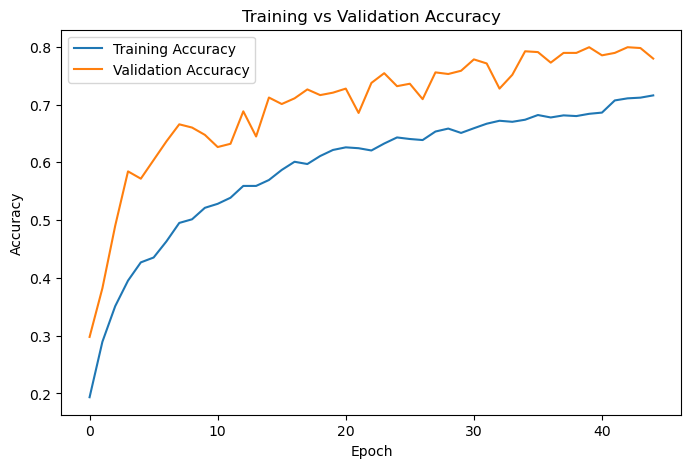

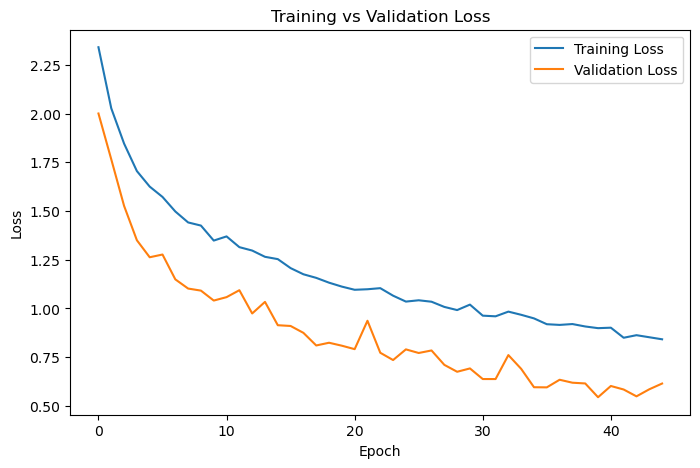

In [18]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.savefig("Figures/TrainAccuracy.png", dpi=300, bbox_inches="tight")
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.savefig("Figures/TrainLoss.png", dpi=300, bbox_inches="tight")
plt.show()

The training and validation curves help evaluate learning behavior, convergence, and generalization. Similar trends between training and validation performance indicate stable learning, while large divergence may suggest overfitting or underfitting.

### Test set metrics


In [19]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import numpy as np

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Accuracy: 0.8260869565217391
              precision    recall  f1-score   support

           0       0.57      0.10      0.17        39
           1       0.85      0.91      0.88        58
           2       0.81      0.88      0.84        43
           3       0.86      0.95      0.90        92
           4       0.91      0.88      0.89        33
           5       0.90      0.76      0.83        72
           6       0.71      0.93      0.81        98
           7       0.94      0.88      0.91        33
           8       0.74      0.86      0.80        78
           9       0.60      0.44      0.51        34
          10       0.92      0.96      0.94        75
          11       0.96      0.84      0.90        58

    accuracy                           0.83       713
   macro avg       0.81      0.78      0.78       713
weighted avg       0.82      0.83      0.81       713



## Confusion Matrix

The confusion matrix visualizes correct and incorrect classifications across plant species categories and helps identify misclassification patterns.

In [20]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 4  0  0  0  1  0 33  0  0  0  1  0]
 [ 0 53  1  0  0  0  0  0  1  1  2  0]
 [ 0  3 38  0  0  1  0  0  1  0  0  0]
 [ 0  0  0 87  1  0  0  0  3  0  1  0]
 [ 0  0  1  2 29  1  0  0  0  0  0  0]
 [ 0  4  4  2  0 55  3  0  1  2  0  1]
 [ 3  0  0  0  1  1 91  0  1  0  1  0]
 [ 0  0  0  1  0  1  0 29  0  0  1  1]
 [ 0  0  0  2  0  1  0  1 67  7  0  0]
 [ 0  1  1  6  0  1  0  0 10 15  0  0]
 [ 0  1  0  1  0  0  1  0  0  0 72  0]
 [ 0  0  2  0  0  0  0  1  6  0  0 49]]


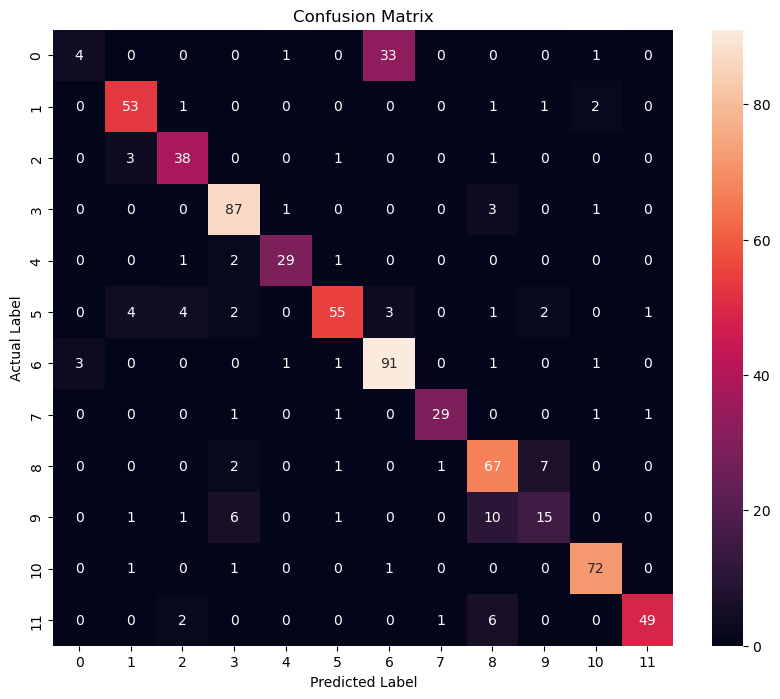

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.savefig("Figures/ConfusionMat.png", dpi=300, bbox_inches="tight")
plt.show()

The confusion matrix highlights correct classifications and reveals species categories that are visually difficult to distinguish.